In [1]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [2]:
import os

DATA_DIR = "/content/Data/Garbage_Classification"

print(os.listdir(DATA_DIR))

['Plastic', 'Cardboard', 'Metal', 'Clothes', 'Glass', 'Battery', 'Paper']


In [3]:
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        print(class_name, ":", len(os.listdir(class_path)))

Plastic : 385
Cardboard : 403
Metal : 769
Clothes : 432
Glass : 775
Battery : 775
Paper : 594


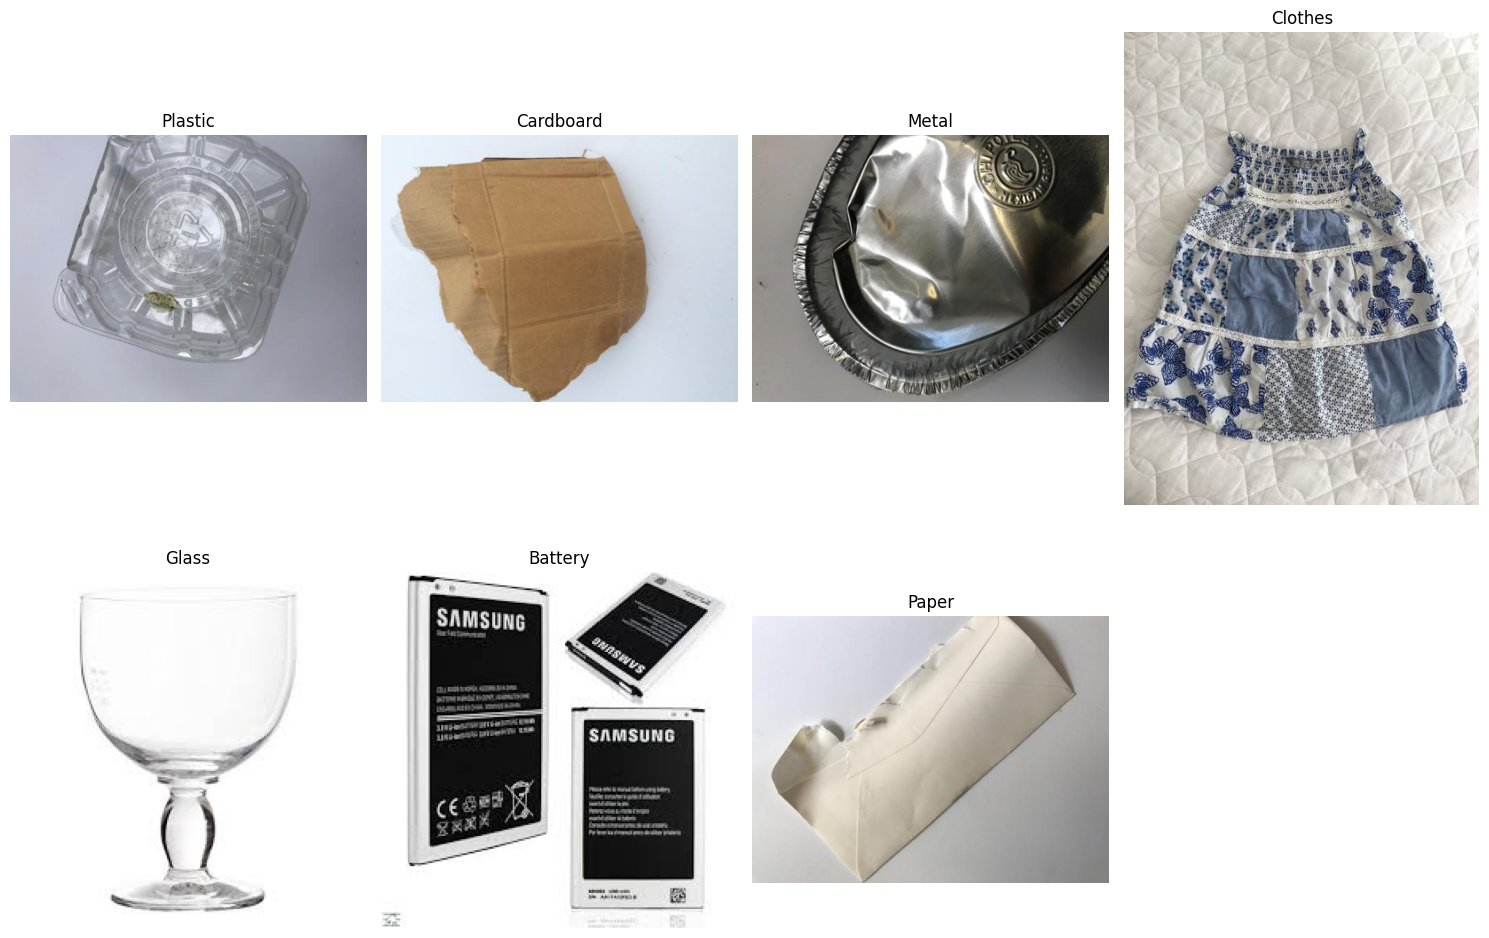

In [4]:
import matplotlib.pyplot as plt
import os
from PIL import Image

classes = os.listdir(DATA_DIR)

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(classes):
    class_path = os.path.join(DATA_DIR, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 4133 files belonging to 7 classes.
Using 3307 files for training.
Found 4133 files belonging to 7 classes.
Using 826 files for validation.


In [6]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Rescaling
)

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [9]:
model = Sequential([
    data_augmentation,
    Rescaling(1./255, input_shape=(224, 224, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True
)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.3429 - loss: 1.7226 - val_accuracy: 0.4407 - val_loss: 1.4566
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.4648 - loss: 1.4173 - val_accuracy: 0.4346 - val_loss: 1.4004
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.5032 - loss: 1.2791 - val_accuracy: 0.4613 - val_loss: 1.3225
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.5488 - loss: 1.1866 - val_accuracy: 0.5182 - val_loss: 1.2347
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.5679 - loss: 1.1282 - val_accuracy: 0.6053 - val_loss: 1.0781
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.5993 - loss: 1.0648 - val_accuracy: 0.5823 - val_loss: 1.0838
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.6223 - loss: 1.0187 - val_accuracy: 0.6525 - val_loss: 1.0060
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6383 - loss: 0.9685 - val_a

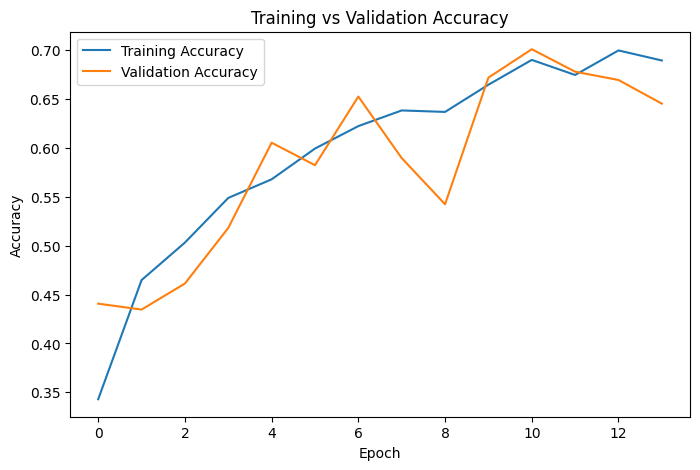

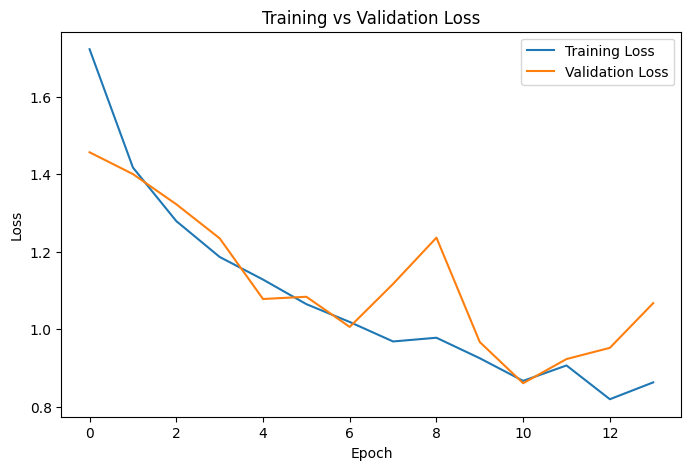

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [15]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7010 - loss: 0.8607
Validation Loss: 0.8607497215270996
Validation Accuracy: 0.7009685039520264


In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [17]:
class_names = ['Battery', 'Cardboard', 'Clothes', 'Glass',
 'Metal', 'Paper', 'Plastic']

In [18]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     Battery       0.81      0.87      0.84       139
   Cardboard       0.88      0.64      0.74        92
     Clothes       0.66      0.87      0.75        79
       Glass       0.76      0.61      0.68       143
       Metal       0.58      0.62      0.60       168
       Paper       0.63      0.87      0.73       111
     Plastic       0.74      0.45      0.56        94

    accuracy                           0.70       826
   macro avg       0.72      0.70      0.70       826
weighted avg       0.72      0.70      0.70       826



In [19]:
#Transfer learning
#Using MobileNet
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

In [20]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
model_mobile = Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

In [22]:
model_mobile.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history_mobile = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.5050 - loss: 1.3661 - val_accuracy: 0.6150 - val_loss: 1.1203
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.6030 - loss: 1.1057 - val_accuracy: 0.6380 - val_loss: 1.0214
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.6405 - loss: 1.0095 - val_accuracy: 0.6501 - val_loss: 0.9937


In [24]:
val_loss, val_accuracy = model_mobile.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6150 - loss: 1.1203
Validation Loss: 1.1203147172927856
Validation Accuracy: 0.6150121092796326


In [25]:
base_model.trainable = True

In [26]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [27]:
model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
history_fine = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.4109 - loss: 1.7425 - val_accuracy: 0.6126 - val_loss: 1.1235
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.4971 - loss: 1.3892 - val_accuracy: 0.6162 - val_loss: 1.1286
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.5579 - loss: 1.2586 - val_accuracy: 0.6150 - val_loss: 1.1110


In [29]:
val_loss, val_accuracy = model_mobile.evaluate(val_ds)

print("Fine-tuned Validation Loss:", val_loss)
print("Fine-tuned Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6126 - loss: 1.1235
Fine-tuned Validation Loss: 1.1235191822052002
Fine-tuned Validation Accuracy: 0.6125907897949219


In [30]:
y_true_mobile = []
y_pred_mobile = []

for images, labels in val_ds:
    predictions = model_mobile.predict(images, verbose=0)

    y_true_mobile.extend(labels.numpy())
    y_pred_mobile.extend(np.argmax(predictions, axis=1))

y_true_mobile = np.array(y_true_mobile)
y_pred_mobile = np.array(y_pred_mobile)

print(classification_report(
    y_true_mobile,
    y_pred_mobile,
    target_names=class_names
))

              precision    recall  f1-score   support

     Battery       0.61      0.91      0.73       139
   Cardboard       0.78      0.57      0.65        92
     Clothes       0.66      0.85      0.74        79
       Glass       0.56      0.58      0.57       143
       Metal       0.59      0.67      0.63       168
       Paper       0.57      0.53      0.55       111
     Plastic       0.62      0.05      0.10        94

    accuracy                           0.61       826
   macro avg       0.63      0.59      0.57       826
weighted avg       0.62      0.61      0.58       826



In [31]:
#Using EfficientNet
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0

In [32]:
base_model2 = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [33]:
base_model2.trainable = False

In [34]:
model_eff = Sequential([
    data_augmentation,
    base_model2,

    tf.keras.layers.GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

In [35]:
model_eff.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
history_eff = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 24s 132ms/step - accuracy: 0.7868 - loss: 0.6183 - val_accuracy: 0.9128 - val_loss: 0.2680
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9129 - loss: 0.2654 - val_accuracy: 0.9116 - val_loss: 0.2488
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9265 - loss: 0.2127 - val_accuracy: 0.9249 - val_loss: 0.2325
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.9320 - loss: 0.1912 - val_accuracy: 0.9237 - val_loss: 0.2287
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.9462 - loss: 0.1628 - val_accuracy: 0.9383 - val_loss: 0.1961
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9498 - loss: 0.1418 - val_accuracy: 0.9358 - val_loss: 0.1962
Epoch 7/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9601 - loss: 0.1150 - val_accuracy: 0.9358 - val_loss: 0.1946
Epoch 8/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9583 - loss: 0.11

In [37]:
val_loss, val_accuracy = model_eff.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9383 - loss: 0.1961
Validation Loss: 0.19606609642505646
Validation Accuracy: 0.9382566809654236


In [38]:
base_model2.trainable = True

In [39]:
for layer in base_model2.layers[:-30]:
    layer.trainable = False

In [40]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
history_fine2 = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 27s 143ms/step - accuracy: 0.8606 - loss: 0.4434 - val_accuracy: 0.9310 - val_loss: 0.2310
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.8863 - loss: 0.3626 - val_accuracy: 0.9262 - val_loss: 0.2479
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - accuracy: 0.9165 - loss: 0.2963 - val_accuracy: 0.9274 - val_loss: 0.2492


In [42]:
val_loss, val_accuracy = model_eff.evaluate(val_ds)

print("Fine-tuned Validation Loss:", val_loss)
print("Fine-tuned Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9310 - loss: 0.2310
Fine-tuned Validation Loss: 0.23102732002735138
Fine-tuned Validation Accuracy: 0.9309927225112915


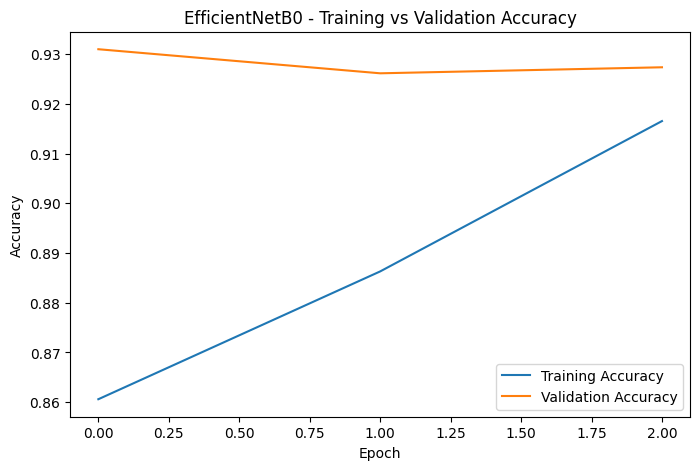

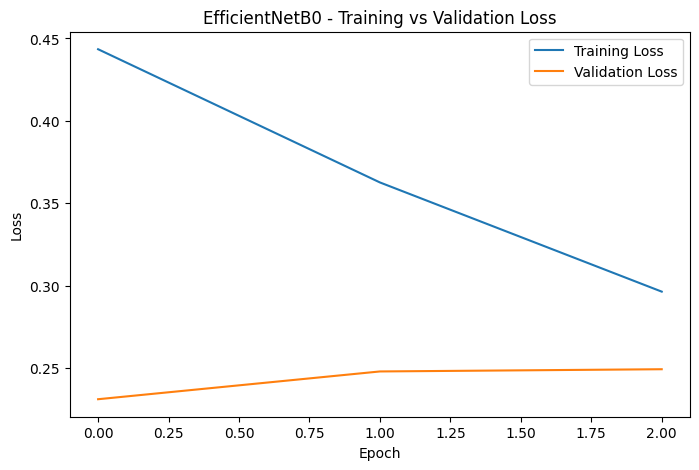

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(history_fine2.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine2.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('EfficientNetB0 - Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history_fine2.history['loss'], label='Training Loss')
plt.plot(history_fine2.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('EfficientNetB0 - Training vs Validation Loss')
plt.legend()
plt.show()

In [44]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model_eff.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     Battery       0.97      0.96      0.96       139
   Cardboard       0.97      0.90      0.93        92
     Clothes       0.96      1.00      0.98        79
       Glass       0.93      0.91      0.92       143
       Metal       0.88      0.94      0.91       168
       Paper       0.92      0.94      0.93       111
     Plastic       0.93      0.87      0.90        94

    accuracy                           0.93       826
   macro avg       0.94      0.93      0.93       826
weighted avg       0.93      0.93      0.93       826



In [45]:
model_eff.save("waste_classifier.keras")

In [46]:
import json

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print("Class names saved to 'class_names.json'")

Class names saved to 'class_names.json'
